### Import

In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

### Define ticker list

In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

### Set Date

In [3]:
start_date = (datetime.now() - timedelta(days=365*5)).strftime('%Y-%m-%d')
end_date = datetime.now().strftime('%Y-%m-%d')

### Download Close Prices

In [4]:
close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date)
    print(data)
    close_df[ticker] = data["Close"]

[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-03-01  124.466904  124.603262  119.596925  120.531960  116307900
2021-03-02  121.866341  125.372724  121.759201  125.070787  102260900
2021-03-03  118.885895  122.440980  118.671615  121.564383  112966300
2021-03-04  117.006081  120.385846  115.535353  118.583956  178155000
2021-03-05  118.262520  118.769002  114.512639  117.833967  153766600
...                ...         ...         ...         ...        ...
2026-02-20  264.579987  264.750000  258.160004  258.970001   42070500
2026-02-23  266.179993  269.429993  263.380005  263.489990   37308200
2026-02-24  272.140015  274.890015  267.709991  267.859985   47014600
2026-02-25  274.230011  274.940002  271.049988  271.779999   33627000
2026-02-26  271.609985  276.109985  270.795013  274.954987   15980133

[1255 rows x 5 colu

[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2021-03-01  227.358047  227.866613  223.721309  226.360097  25324000
2021-03-02  224.412201  227.703498  224.009188  227.425218  22812500
2021-03-03  218.357376  224.133929  218.069505  222.771356  34029500
2021-03-04  217.560913  223.087985  215.190800  217.570518  44727800
2021-03-05  222.233994  223.836456  217.301858  220.238108  41872800
...                ...         ...         ...         ...       ...
2026-02-20  397.230011  400.119995  395.160004  396.109985  34015200
2026-02-23  384.470001  395.359985  383.100006  395.000000  43238300
2026-02-24  389.000000  389.359985  381.709991  384.140015  33884700
2026-02-25  400.600006  401.470001  390.160004  390.529999  43514700
2026-02-26  400.850006  407.489990  398.739990  404.635010  21208546

[1255 rows x 5 columns]


[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open    Volume
Ticker           GOOGL       GOOGL       GOOGL       GOOGL     GOOGL
Date                                                                
2021-03-01  102.706970  103.033006  100.958183  101.632092  26060000
2021-03-02  102.449913  103.951567  102.062346  102.467776  25564000
2021-03-03   99.816307  103.021089   98.952329  101.828107  33892000
2021-03-04  100.933868  102.951620   99.519552   99.988012  49216000
2021-03-05  104.067192  104.520266  100.628672  102.284663  53100000
...                ...         ...         ...         ...       ...
2026-02-20  314.980011  316.500000  303.899994  304.320007  53210800
2026-02-23  311.489990  319.519989  309.869995  319.049988  31423000
2026-02-24  310.899994  312.269989  305.929993  310.519989  25615600
2026-02-25  312.899994  313.640015  309.440002  312.059998  29896500
2026-02-26  306.440002  313.140015  302.345001  312.640015  23490743

[1255 rows x 5 columns]


[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open     Volume
Ticker            AMZN        AMZN        AMZN        AMZN       AMZN
Date                                                                 
2021-03-01  157.307007  157.477997  154.899506  156.394501   54582000
2021-03-02  154.726501  158.175995  154.356003  157.173492   51916000
2021-03-03  150.250000  155.389008  149.750000  154.059006   79774000
2021-03-04  148.878494  152.906494  147.271500  150.600006  109632000
2021-03-05  150.022995  150.449997  144.050003  150.250000  107772000
...                ...         ...         ...         ...        ...
2026-02-20  210.110001  211.169998  203.750000  204.759995   65881600
2026-02-23  205.270004  208.429993  203.110001  208.100006   53581500
2026-02-24  208.559998  210.360001  203.250000  205.470001   41137200
2026-02-25  210.639999  211.589996  208.929993  210.460007   41199700
2026-02-26  206.199997  211.050003  205.349899  210.729996   28044439

[1255 rows x 5 colu

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2021-03-01  239.476669  239.666672  228.350006  230.036667   81408600
2021-03-02  228.813339  240.369995  228.333328  239.426666   71196600
2021-03-03  217.733337  233.566666  217.236664  229.330002   90624000
2021-03-04  207.146667  222.816666  200.000000  218.600006  197758500
2021-03-05  199.316666  209.279999  179.830002  208.686661  268189500
...                ...         ...         ...         ...        ...
2026-02-20  411.820007  414.700012  405.500000  408.299988   57912200
2026-02-23  399.829987  407.700012  394.040009  407.290009   69680000
2026-02-24  409.380005  410.820007  397.640015  399.500000   58579500
2026-02-25  417.399994  420.339996  412.149994  412.149994   54649200
2026-02-26  406.869904  416.799988  403.660004  414.500000   37454544

[1255 rows x 5 colu

### Display

In [5]:
print(close_df.head())

                  AAPL        MSFT       GOOGL        AMZN        TSLA
Date                                                                  
2021-03-01  124.466904  227.358047  102.706970  157.307007  239.476669
2021-03-02  121.866341  224.412201  102.449913  154.726501  228.813339
2021-03-03  118.885895  218.357376   99.816307  150.250000  217.733337
2021-03-04  117.006081  217.560913  100.933868  148.878494  207.146667
2021-03-05  118.262520  222.233994  104.067192  150.022995  199.316666


### Calculate Lognormal returns

In [6]:
log_returns = np.log(close_df / close_df.shift(1)).dropna()

### Calculate covariance matrix

In [7]:
cov_matrix = log_returns.cov()*252
print(cov_matrix)

           AAPL      MSFT     GOOGL      AMZN      TSLA
AAPL   0.075945  0.043534  0.048986  0.053597  0.080298
MSFT   0.043534  0.068786  0.049666  0.059100  0.065004
GOOGL  0.048986  0.049666  0.094839  0.067401  0.076084
AMZN   0.053597  0.059100  0.067401  0.124287  0.093227
TSLA   0.080298  0.065004  0.076084  0.093227  0.357375


### Calculate portfolio standard deviation

In [8]:
def standard_deviation(weights, cov_matrix):
    variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    return np.sqrt(variance)

### Calculate expected return

In [9]:
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean() * weights) * 252

### Calculate the sharpe ratio

In [10]:
def sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return (expected_return(weights, log_returns) - risk_free_rate) / standard_deviation(weights, cov_matrix)

### Risk free rate (IDK)

### Calculate the negative sharpe ratio(Minimize)

In [11]:
def negative_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

### Set constraints and bounds

In [12]:
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 0.5) for _ in range(len(tickers)))

### Set initial weight

In [13]:
initial_weights = np.array([1/len(tickers)] * len(tickers))
print(initial_weights)

[0.2 0.2 0.2 0.2 0.2]


### Optimize weight => Maximize Sharpe Ratio

In [14]:
optimized_result = minimize(negative_sharpe_ratio, initial_weights, args=(log_returns, cov_matrix, 0.01), method='SLSQP', bounds=bounds, constraints=constraints)

### Optimal weight

In [15]:
optimal_weights = optimized_result.x

### Display analytics of the optimal portfolio

In [16]:
print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

print()

optimal_portfolio_return = expected_return(optimal_weights, log_returns)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, 0.01)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Annual Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
AAPL: 0.5000
MSFT: 0.0000
GOOGL: 0.5000
AMZN: 0.0000
TSLA: 0.0000

Expected Annual Return: 0.1882
Annual Volatility: 0.2592
Sharpe Ratio: 0.6876


### Display portfolio in a plot

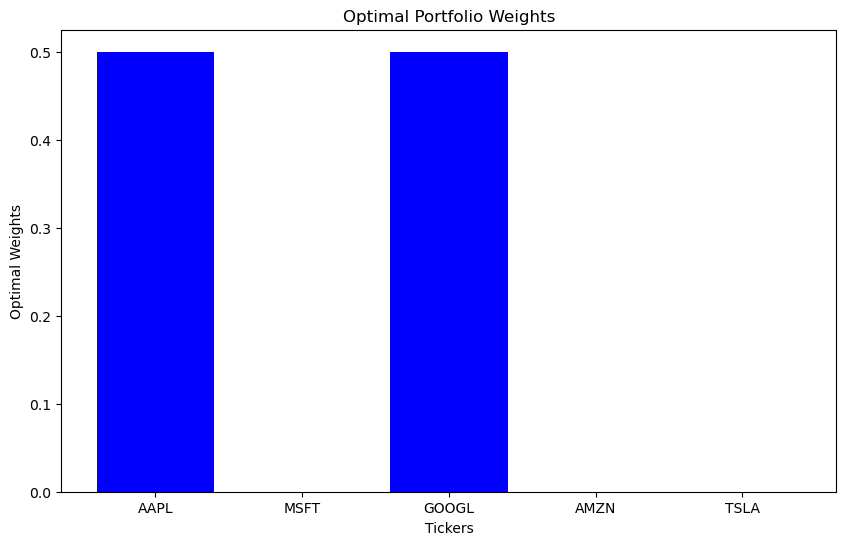

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights, color='blue')
plt.xlabel('Tickers')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')
plt.show()